Étape 1 — Imports

In [1]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

Étape 2 — Chargement des données

In [2]:
fichiers = glob.glob("eCO2mix_RTE_Annuel-Definitif_*.xls")
print(f"{len(fichiers)} fichiers trouvés")

dfs = []
for fichier in fichiers:
    df_temp = pd.read_csv(
        fichier,
        sep="\t",
        encoding="latin1",
        index_col=False,
        low_memory=False
    )
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)
print(f"Dimensions : {df.shape}")

13 fichiers trouvés
Dimensions : (429517, 40)


Étape 3 — Nettoyage

In [4]:
# Aperçu des premières lignes
df.head(5)

,Périmètre,Nature,Date,Heures,Consommation,Prévision J-1,Prévision J,Fioul,Charbon,Gaz,...,Hydraulique - Fil de l?eau + éclusée,Hydraulique - Lacs,Hydraulique - STEP turbinage,Bioénergies - Déchets,Bioénergies - Biomasse,Bioénergies - Biogaz,Stockage batterie,Déstockage batterie,Eolien terrestre,Eolien offshore
0,France,Données définitives,2012-01-01,00:00,58315.0,58200.0,58200.0,492.0,25.0,3816.0,...,ND,ND,ND,ND,ND,ND,NaN,NaN,NaN,NaN
1,France,Données définitives,2012-01-01,00:15,NaN,57700.0,57550.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,France,Données définitives,2012-01-01,00:30,58315.0,57200.0,56900.0,492.0,25.0,3816.0,...,ND,ND,ND,ND,ND,ND,NaN,NaN,NaN,NaN
3,France,Données définitives,2012-01-01,00:45,NaN,56200.0,56000.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,France,Données définitives,2012-01-01,01:00,56231.0,55200.0,55100.0,492.0,25.0,3834.0,...,ND,ND,ND,ND,ND,ND,NaN,NaN,NaN,NaN


In [5]:
# Infos générales
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 429517 entries, 0 to 429516
Data columns (total 40 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Périmètre                             429517 non-null  str    
 1   Nature                                429504 non-null  str    
 2   Date                                  429504 non-null  str    
 3   Heures                                429504 non-null  str    
 4   Consommation                          214752 non-null  float64
 5   Prévision J-1                         429504 non-null  float64
 6   Prévision J                           429504 non-null  float64
 7   Fioul                                 214752 non-null  float64
 8   Charbon                               214752 non-null  float64
 9   Gaz                                   214752 non-null  float64
 10  Nucléaire                             214752 non-null  float64
 11  Eolien     

In [6]:
# On garde seulement les 3 colonnes utiles
df = df[["Date", "Heures", "Consommation"]].copy()

# On supprime les lignes sans date ni heure
df = df.dropna(subset=["Date", "Heures"])

# On convertit la consommation en numérique
df["Consommation"] = pd.to_numeric(df["Consommation"], errors="coerce")

# On supprime les lignes sans consommation
avant = len(df)
df = df.dropna(subset=["Consommation"]).reset_index(drop=True)
apres = len(df)

print(f"Lignes supprimées : {avant - apres}")
print(f"Lignes restantes  : {apres}")

Lignes supprimées : 214752
Lignes restantes  : 214752


Étape 4 — Feature Engineering

On crée de nouvelles variables à partir de la date et de l'heure.
C'est ce que le modèle va utiliser pour apprendre.

- hour        : heure de la journée (0-23)
- day_of_week : jour de la semaine (0=lundi, 6=dimanche)
- month       : mois de l'année → effet saisonnier
- day         : jour du mois
- year        : année → tendance long terme
- is_weekend  : 1 si samedi/dimanche, 0 sinon

In [7]:
# Création du datetime combiné
df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Heures"])

# Extraction des variables temporelles
df["hour"]        = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.dayofweek
df["month"]       = df["datetime"].dt.month
df["day"]         = df["datetime"].dt.day
df["year"]        = df["datetime"].dt.year
df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)

# Vérification
df[["datetime", "hour", "day_of_week", "month", "year", "is_weekend", "Consommation"]].head(10)

,datetime,hour,day_of_week,month,year,is_weekend,Consommation
0,2012-01-01 00:00:00,0,6,1,2012,1,58315.0
1,2012-01-01 00:30:00,0,6,1,2012,1,58315.0
2,2012-01-01 01:00:00,1,6,1,2012,1,56231.0
3,2012-01-01 01:30:00,1,6,1,2012,1,56075.0
4,2012-01-01 02:00:00,2,6,1,2012,1,55532.0
5,2012-01-01 02:30:00,2,6,1,2012,1,54911.0
6,2012-01-01 03:00:00,3,6,1,2012,1,52496.0
7,2012-01-01 03:30:00,3,6,1,2012,1,50664.0
8,2012-01-01 04:00:00,4,6,1,2012,1,49161.0
9,2012-01-01 04:30:00,4,6,1,2012,1,47596.0


Étape 5 — Visualisation exploratoire


Avant de modéliser, on visualise la consommation moyenne 
en fonction de chaque variable temporelle pour vérifier 
que nos features sont bien liées à la cible.

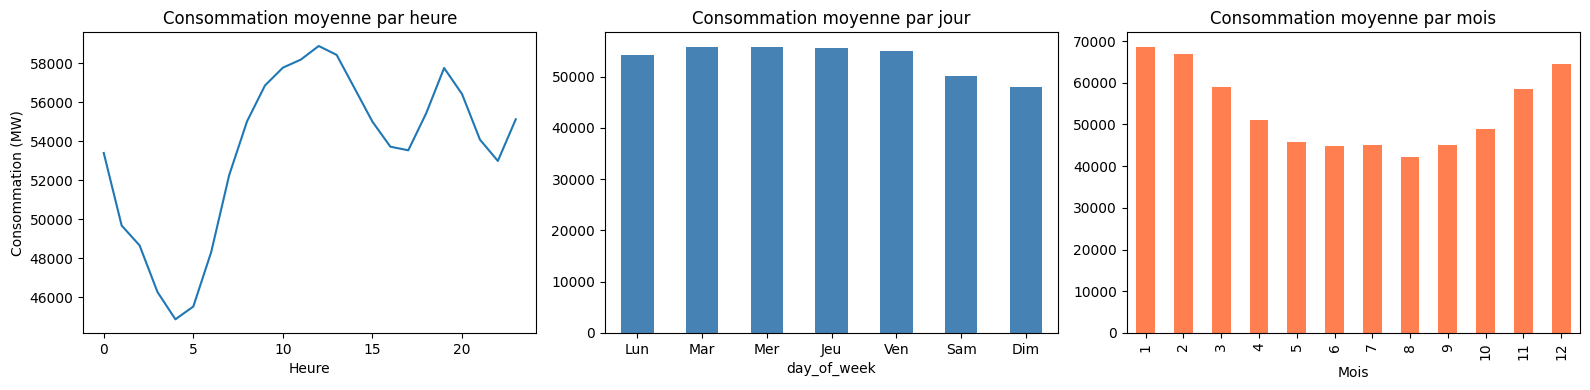

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Par heure
df.groupby("hour")["Consommation"].mean().plot(ax=axes[0])
axes[0].set_title("Consommation moyenne par heure")
axes[0].set_xlabel("Heure")
axes[0].set_ylabel("Consommation (MW)")

# Par jour de la semaine
df.groupby("day_of_week")["Consommation"].mean().plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Consommation moyenne par jour")
axes[1].set_xticklabels(["Lun","Mar","Mer","Jeu","Ven","Sam","Dim"], rotation=0)

# Par mois
df.groupby("month")["Consommation"].mean().plot(kind="bar", ax=axes[2], color="coral")
axes[2].set_title("Consommation moyenne par mois")
axes[2].set_xlabel("Mois")

plt.tight_layout()
plt.show()

Étape 6 — Préparation du split temporel


On coupe les données dans le temps : 
- Entraînement : 2012–2021
- Test : 2022–2024

On ne mélange PAS aléatoirement car les données sont 
chronologiques. Un split aléatoire laisserait le modèle 
"voir le futur" pendant l'entraînement, ce qui fausserait 
les performances.

In [9]:
features = ["hour", "day_of_week", "month", "day", "year", "is_weekend"]
X = df[features]
y = df["Consommation"]

train_mask = df["year"] <= 2021
test_mask  = df["year"] >= 2022

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Entraînement : {len(X_train):,} lignes ({X_train['year'].min()}–{X_train['year'].max()})")
print(f"Test         : {len(X_test):,} lignes ({X_test['year'].min()}–{X_test['year'].max()})")

Entraînement : 175,344 lignes (2012–2021)
Test         : 39,408 lignes (2022–2024)


Étape 7 — Modèle 1 : Régression linéaire

Modèle 1 : Régression linéaire
Le modèle le plus simple. Il cherche une combinaison linéaire 
des features pour prédire la consommation.
Avantages : rapide, interprétable
Limites : ne capte pas les relations non-linéaires

Métriques :
- RMSE : erreur moyenne en MW (plus c'est petit, mieux c'est)
- R²   : proportion de variance expliquée (1 = parfait, 0 = inutile)

In [10]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print("=== Régression linéaire ===")
print(f"RMSE : {rmse_lr:.1f} MW")
print(f"R²   : {r2_lr:.4f}")

=== Régression linéaire ===
RMSE : 9833.6 MW
R²   : 0.1980


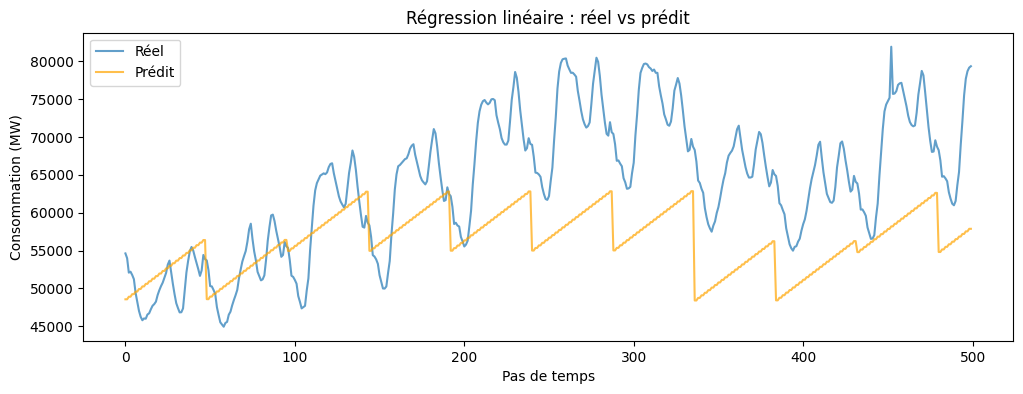

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:500], label="Réel", alpha=0.7)
plt.plot(y_pred_lr[:500], label="Prédit", alpha=0.7, color="orange")
plt.title("Régression linéaire : réel vs prédit")
plt.xlabel("Pas de temps")
plt.ylabel("Consommation (MW)")
plt.legend()
plt.show()

Étape 8 — Modèle 2 : Random Forest

Modèle 2 : Random Forest
Ensemble d'arbres de décision capable de capter des relations 
non-linéaires et des interactions entre variables.
Ex : l'effet de l'heure EST différent selon le mois → 
la régression linéaire ne peut pas voir ça, le Random Forest si.
Attention : l'entraînement peut prendre 1-2 minutes.

In [12]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print("=== Random Forest ===")
print(f"RMSE : {rmse_rf:.1f} MW")
print(f"R²   : {r2_rf:.4f}")

=== Random Forest ===
RMSE : 6917.6 MW
R²   : 0.6031


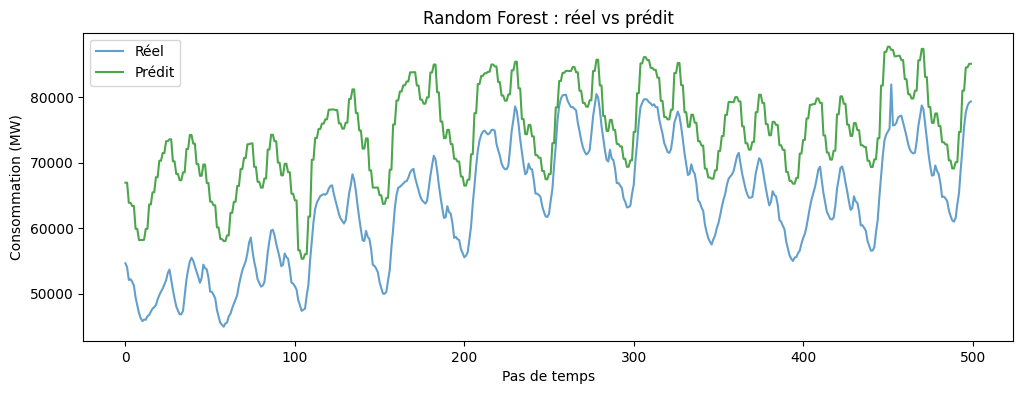

In [13]:
plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:500], label="Réel", alpha=0.7)
plt.plot(y_pred_rf[:500], label="Prédit", alpha=0.7, color="green")
plt.title("Random Forest : réel vs prédit")
plt.xlabel("Pas de temps")
plt.ylabel("Consommation (MW)")
plt.legend()
plt.show()

Nous allons maintenant prendre en compte les années avec des évenements qui peuvent avoir eu un impact sur la consommation (Covid, guerre en Ukraine, guerre en Iran...)

Modèle A — Sans les années Covid

Modèle A : Random Forest sans 2020-2021
On exclut les années Covid de l'entraînement car elles 
représentent une anomalie qui fausse ce que le modèle apprend 
comme "normal".

In [14]:
# On exclut 2020 et 2021 de l'entraînement
train_mask_A = (df["year"] <= 2019)
test_mask    = (df["year"] >= 2022)

X_train_A = df.loc[train_mask_A, features]
y_train_A = df.loc[train_mask_A, "Consommation"]
X_test_A  = df.loc[test_mask, features]
y_test_A  = df.loc[test_mask, "Consommation"]

print(f"Entraînement : {len(X_train_A):,} lignes ({X_train_A['year'].min()}–{X_train_A['year'].max()})")
print(f"Test         : {len(X_test_A):,} lignes ({X_test_A['year'].min()}–{X_test_A['year'].max()})")

Entraînement : 140,256 lignes (2012–2019)
Test         : 39,408 lignes (2022–2024)


In [15]:
rf_A = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_A.fit(X_train_A, y_train_A)

y_pred_A = rf_A.predict(X_test_A)

rmse_A = np.sqrt(mean_squared_error(y_test_A, y_pred_A))
r2_A   = r2_score(y_test_A, y_pred_A)

print("=== Modèle A : RF sans 2020-2021 ===")
print(f"RMSE : {rmse_A:.1f} MW")
print(f"R²   : {r2_A:.4f}")

=== Modèle A : RF sans 2020-2021 ===
RMSE : 6438.5 MW
R²   : 0.6562


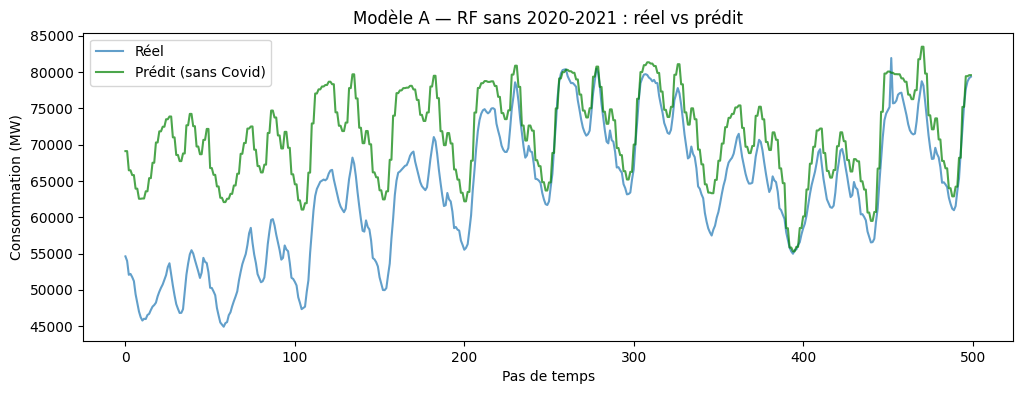

In [16]:
plt.figure(figsize=(12, 4))
plt.plot(y_test_A.values[:500], label="Réel", alpha=0.7)
plt.plot(y_pred_A[:500], label="Prédit (sans Covid)", alpha=0.7, color="green")
plt.title("Modèle A — RF sans 2020-2021 : réel vs prédit")
plt.xlabel("Pas de temps")
plt.ylabel("Consommation (MW)")
plt.legend()
plt.show()

Modèle B — Avec variable evenement

Modèle B : RF avec variable "evenement"
On ajoute une variable catégorielle qui encode les grandes 
périodes de rupture de consommation :
- 0 : période normale (2012-2019)
- 1 : Covid (2020-2021) → chute temporaire
- 2 : Crise énergétique + sobriété (2022-2024) → baisse structurelle
On pourrait ajouter d'autres événements si les données 
le permettaient (ex: guerre Iran).

In [17]:
# Ajout de la variable evenement sur tout le DataFrame
def encoder_evenement(year):
    if year in [2020, 2021]:
        return 1  # Covid
    elif year >= 2022:
        return 2  # Crise énergie / sobriété
    else:
        return 0  # Normal

df["evenement"] = df["year"].apply(encoder_evenement)

# Vérification
df.groupby("evenement")["year"].unique()

evenement
0    [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
1                                        [2020, 2021]
2                                  [2022, 2023, 2024]
Name: year, dtype: object

In [18]:
# Nouvelles features avec la variable evenement
features_B = ["hour", "day_of_week", "month", "day", "year", "is_weekend", "evenement"]

X_B = df[features_B]
y_B = df["Consommation"]

# Même split temporel : train 2012-2021, test 2022-2024
train_mask_B = df["year"] <= 2021
test_mask_B  = df["year"] >= 2022

X_train_B = X_B[train_mask_B]
y_train_B = y_B[train_mask_B]
X_test_B  = X_B[test_mask_B]
y_test_B  = y_B[test_mask_B]

print(f"Entraînement : {len(X_train_B):,} lignes")
print(f"Test         : {len(X_test_B):,} lignes")

Entraînement : 175,344 lignes
Test         : 39,408 lignes


In [19]:
rf_B = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_B.fit(X_train_B, y_train_B)

y_pred_B = rf_B.predict(X_test_B)

rmse_B = np.sqrt(mean_squared_error(y_test_B, y_pred_B))
r2_B   = r2_score(y_test_B, y_pred_B)

print("=== Modèle B : RF avec variable événement ===")
print(f"RMSE : {rmse_B:.1f} MW")
print(f"R²   : {r2_B:.4f}")

=== Modèle B : RF avec variable événement ===
RMSE : 6917.5 MW
R²   : 0.6031


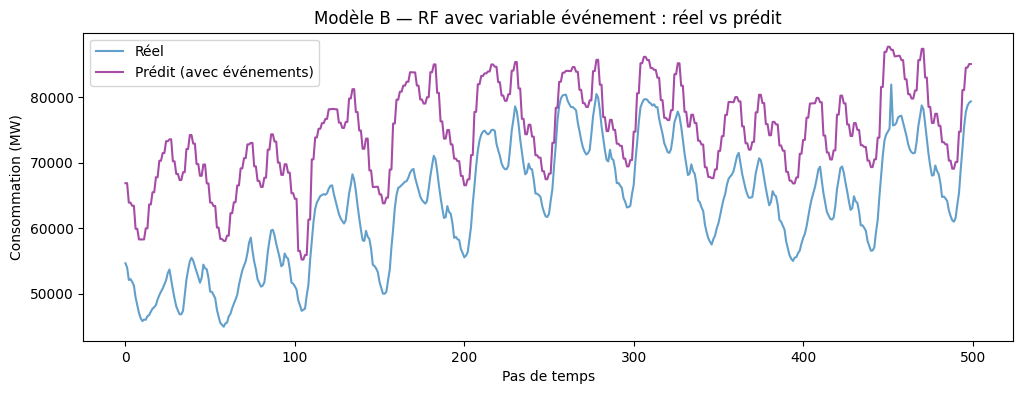

In [20]:
plt.figure(figsize=(12, 4))
plt.plot(y_test_B.values[:500], label="Réel", alpha=0.7)
plt.plot(y_pred_B[:500], label="Prédit (avec événements)", alpha=0.7, color="purple")
plt.title("Modèle B — RF avec variable événement : réel vs prédit")
plt.xlabel("Pas de temps")
plt.ylabel("Consommation (MW)")
plt.legend()
plt.show()

## Modèle C : RF avec variables de crise enrichies
On remplace la variable binaire evenement par 3 variables 
plus informatives calculées directement depuis les données :
- conso_moy_annee_prec : consommation moyenne de l'année précédente
- ecart_historique     : écart à la moyenne 2012-2019 pour ce mois/heure
- intensite_crise      : valeur continue entre 0 et 1 selon la période

In [21]:
# --- Variable 1 : consommation moyenne par année ---
conso_moy_par_annee = df.groupby("year")["Consommation"].mean()

# On décale d'un an pour avoir la moyenne de l'année PRÉCÉDENTE
conso_moy_par_annee_prec = conso_moy_par_annee.shift(1)
df["conso_moy_annee_prec"] = df["year"].map(conso_moy_par_annee_prec)

# --- Variable 2 : moyenne historique 2012-2019 par mois ET heure ---
df_normal = df[df["year"] <= 2019]
moy_historique = df_normal.groupby(["month", "hour"])["Consommation"].mean()
moy_historique.name = "moy_historique"
df = df.join(moy_historique, on=["month", "hour"])
df["ecart_historique"] = df["Consommation"] - df["moy_historique"]

# --- Variable 3 : intensité de crise progressive ---
def intensite_crise(year):
    if year <= 2019:
        return 0.0   # Période normale
    elif year == 2020:
        return 0.8   # Covid fort
    elif year == 2021:
        return 0.5   # Covid qui s'atténue
    elif year == 2022:
        return 0.9   # Crise énergie intense
    elif year == 2023:
        return 0.6   # Sobriété qui s'installe
    else:
        return 0.4   # Retour progressif

df["intensite_crise"] = df["year"].apply(intensite_crise)

# Vérification
df[["year", "conso_moy_annee_prec", "ecart_historique", "intensite_crise"]].drop_duplicates("year").sort_values("year")

,year,conso_moy_annee_prec,ecart_historique,intensite_crise
0,2012,NaN,-10323.929435,0.0
17568,2013,55396.961806,-7444.929435,0.0
35088,2014,56185.529852,-3978.929435,0.0
52608,2015,52779.499144,5855.070565,0.0
70128,2016,54012.877797,-8473.929435,0.0
87696,2017,54681.287739,7620.070565,0.0
105216,2018,54685.462043,-7511.929435,0.0
122736,2019,54283.219521,-4431.929435,0.0
140256,2020,53707.436301,-1570.929435,0.8
157824,2021,50840.467953,-1482.929435,0.5


In [22]:
# Nouvelles features enrichies
features_C = [
    "hour", "day_of_week", "month", "day", "year", "is_weekend",
    "conso_moy_annee_prec", "ecart_historique", "intensite_crise"
]

X_C = df[features_C]
y_C = df["Consommation"]

train_mask_C = df["year"] <= 2021
test_mask_C  = df["year"] >= 2022

X_train_C = X_C[train_mask_C].dropna()
y_train_C = y_C[X_train_C.index]
X_test_C  = X_C[test_mask_C].dropna()
y_test_C  = y_C[X_test_C.index]

print(f"Entraînement : {len(X_train_C):,} lignes")
print(f"Test         : {len(X_test_C):,} lignes")
print(f"\nFeatures utilisées : {features_C}")

Entraînement : 157,776 lignes
Test         : 39,408 lignes

Features utilisées : ['hour', 'day_of_week', 'month', 'day', 'year', 'is_weekend', 'conso_moy_annee_prec', 'ecart_historique', 'intensite_crise']


In [23]:
rf_C = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_C.fit(X_train_C, y_train_C)

y_pred_C = rf_C.predict(X_test_C)

rmse_C = np.sqrt(mean_squared_error(y_test_C, y_pred_C))
r2_C   = r2_score(y_test_C, y_pred_C)

print("=== Modèle C : RF variables enrichies ===")
print(f"RMSE : {rmse_C:.1f} MW")
print(f"R²   : {r2_C:.4f}")

=== Modèle C : RF variables enrichies ===
RMSE : 481.5 MW
R²   : 0.9981


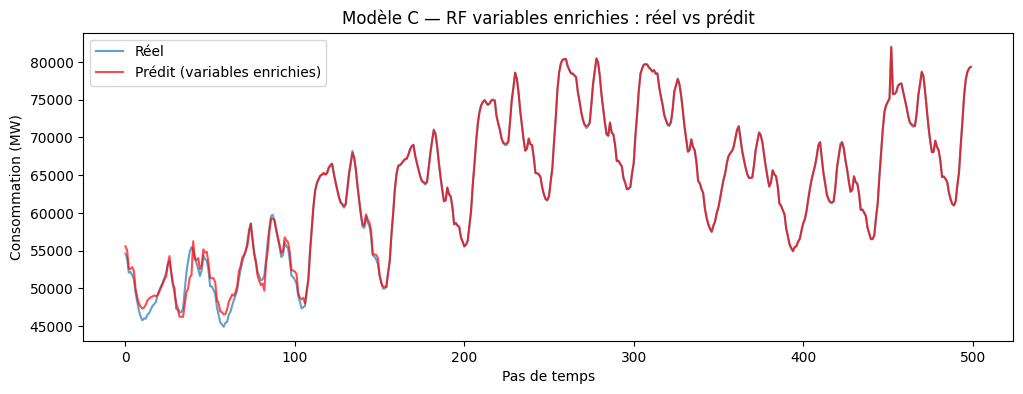

In [24]:
plt.figure(figsize=(12, 4))
plt.plot(y_test_C.values[:500], label="Réel", alpha=0.7)
plt.plot(y_pred_C[:500], label="Prédit (variables enrichies)", alpha=0.7, color="red")
plt.title("Modèle C — RF variables enrichies : réel vs prédit")
plt.xlabel("Pas de temps")
plt.ylabel("Consommation (MW)")
plt.legend()
plt.show()

## Modèle D : RF propre sans data leakage
On remplace ecart_historique (qui utilisait la conso réelle)
par des références historiques connues à l'avance :
- conso moyenne du même mois, l'année précédente
- conso moyenne de la même heure, l'année précédente
Ces variables simulent ce qu'un vrai système de prédiction 
aurait à disposition sans "tricher".


In [25]:
# Variable 1 : conso moyenne par mois ET année précédente
conso_mois_annee = df.groupby(["year", "month"])["Consommation"].mean()
conso_mois_annee = conso_mois_annee.reset_index()
conso_mois_annee.columns = ["year", "month", "conso_moy_mois"]

# On décale d'un an
conso_mois_annee["year_cible"] = conso_mois_annee["year"] + 1
ref_mois = conso_mois_annee[["year_cible", "month", "conso_moy_mois"]].rename(
    columns={"year_cible": "year", "conso_moy_mois": "conso_meme_mois_prec"}
)

df = df.merge(ref_mois, on=["year", "month"], how="left")

# Variable 2 : conso moyenne par heure ET année précédente
conso_heure_annee = df.groupby(["year", "hour"])["Consommation"].mean()
conso_heure_annee = conso_heure_annee.reset_index()
conso_heure_annee.columns = ["year", "hour", "conso_moy_heure"]

conso_heure_annee["year_cible"] = conso_heure_annee["year"] + 1
ref_heure = conso_heure_annee[["year_cible", "hour", "conso_moy_heure"]].rename(
    columns={"year_cible": "year", "conso_moy_heure": "conso_meme_heure_prec"}
)

df = df.merge(ref_heure, on=["year", "hour"], how="left")

# Vérification
df[["year", "month", "hour", "conso_meme_mois_prec", 
    "conso_meme_heure_prec", "conso_moy_annee_prec", 
    "intensite_crise"]].drop_duplicates("year").sort_values("year")

,year,month,hour,conso_meme_mois_prec,conso_meme_heure_prec,conso_moy_annee_prec,intensite_crise
0,2012,1,0,NaN,NaN,NaN,0.0
17568,2013,1,0,68261.475806,55265.259563,55396.961806,0.0
35088,2014,1,0,71633.961022,56172.813699,56185.529852,0.0
52608,2015,1,0,65923.247312,52928.628767,52779.499144,0.0
70128,2016,1,0,70211.567204,54269.976712,54012.877797,0.0
87696,2017,1,0,67031.502688,54969.178962,54681.287739,0.0
105216,2018,1,0,76722.452285,55034.539726,54685.462043,0.0
122736,2019,1,0,65102.593414,54262.280822,54283.219521,0.0
140256,2020,1,0,72308.372984,53611.601370,53707.436301,0.8
157824,2021,1,0,66451.825941,51060.728142,50840.467953,0.5


In [26]:
features_D = [
    "hour", "day_of_week", "month", "day", "year", "is_weekend",
    "intensite_crise",
    "conso_moy_annee_prec",
    "conso_meme_mois_prec",
    "conso_meme_heure_prec"
]

X_D = df[features_D]
y_D = df["Consommation"]

train_mask_D = df["year"] <= 2021
test_mask_D  = df["year"] >= 2022

X_train_D = X_D[train_mask_D].dropna()
y_train_D = y_D[X_train_D.index]
X_test_D  = X_D[test_mask_D].dropna()
y_test_D  = y_D[X_test_D.index]

print(f"Entraînement : {len(X_train_D):,} lignes")
print(f"Test         : {len(X_test_D):,} lignes")
print(f"\nFeatures : {features_D}")

Entraînement : 157,776 lignes
Test         : 39,408 lignes

Features : ['hour', 'day_of_week', 'month', 'day', 'year', 'is_weekend', 'intensite_crise', 'conso_moy_annee_prec', 'conso_meme_mois_prec', 'conso_meme_heure_prec']


In [27]:
rf_D = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_D.fit(X_train_D, y_train_D)

y_pred_D = rf_D.predict(X_test_D)

rmse_D = np.sqrt(mean_squared_error(y_test_D, y_pred_D))
r2_D   = r2_score(y_test_D, y_pred_D)

print("=== Modèle D : RF sans data leakage ===")
print(f"RMSE : {rmse_D:.1f} MW")
print(f"R²   : {r2_D:.4f}")

=== Modèle D : RF sans data leakage ===
RMSE : 5734.2 MW
R²   : 0.7273


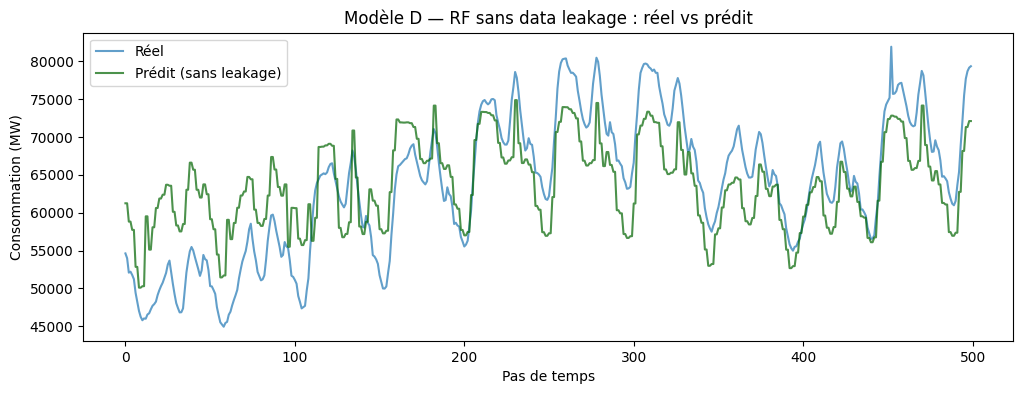

In [28]:
plt.figure(figsize=(12, 4))
plt.plot(y_test_D.values[:500], label="Réel", alpha=0.7)
plt.plot(y_pred_D[:500], label="Prédit (sans leakage)", alpha=0.7, color="darkgreen")
plt.title("Modèle D — RF sans data leakage : réel vs prédit")
plt.xlabel("Pas de temps")
plt.ylabel("Consommation (MW)")
plt.legend()
plt.show()

Comparaison finale de tous les modèles

In [29]:
comparaison = pd.DataFrame({
    "Modèle" : [
        "Régression linéaire",
        "RF complet (2012-2021)",
        "RF sans Covid",
        "RF variable événement",
        "RF variables enrichies (leakage ⚠️)",
        "RF sans data leakage ✅"
    ],
    "RMSE (MW)" : [
        round(rmse_lr, 1),
        round(rmse_rf, 1),
        round(rmse_A, 1),
        round(rmse_B, 1),
        round(rmse_C, 1),
        round(rmse_D, 1)
    ],
    "R²" : [
        round(r2_lr, 4),
        round(r2_rf, 4),
        round(r2_A, 4),
        round(r2_B, 4),
        round(r2_C, 4),
        round(r2_D, 4)
    ]
})
print(comparaison.to_string(index=False))

                             Modèle  RMSE (MW)     R²
                Régression linéaire     9833.6 0.1980
             RF complet (2012-2021)     6917.6 0.6031
                      RF sans Covid     6438.5 0.6562
              RF variable événement     6917.5 0.6031
RF variables enrichies (leakage ⚠️)      481.5 0.9981
             RF sans data leakage ✅     5734.2 0.7273


C:\Users\Fefe\AppData\Local\Temp\ipykernel_29632\1746182476.py:28: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Fefe\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


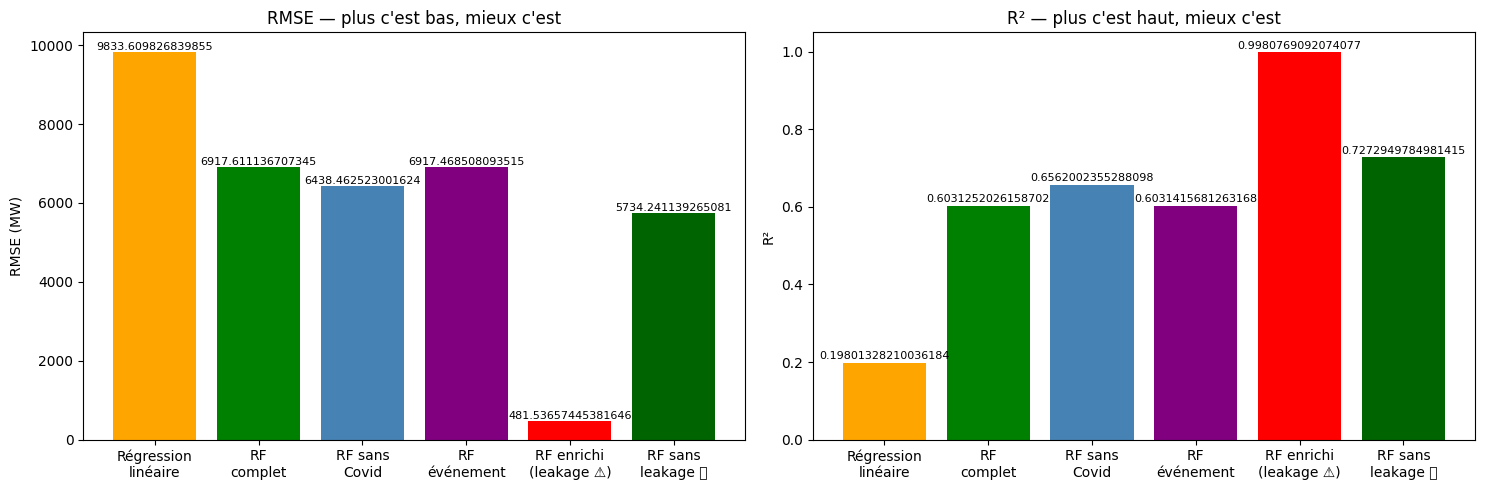

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

modeles = [
    "Régression\nlinéaire",
    "RF\ncomplet",
    "RF sans\nCovid",
    "RF\névénement",
    "RF enrichi\n(leakage ⚠️)",
    "RF sans\nleakage ✅"
]
rmses  = [rmse_lr, rmse_rf, rmse_A, rmse_B, rmse_C, rmse_D]
r2s    = [r2_lr,   r2_rf,   r2_A,   r2_B,   r2_C,   r2_D]
colors = ["orange", "green", "steelblue", "purple", "red", "darkgreen"]

axes[0].bar(modeles, rmses, color=colors)
axes[0].set_title("RMSE — plus c'est bas, mieux c'est")
axes[0].set_ylabel("RMSE (MW)")
for i, v in enumerate(rmses):
    axes[0].text(i, v + 50, str(v), ha="center", fontsize=8)

axes[1].bar(modeles, r2s, color=colors)
axes[1].set_title("R² — plus c'est haut, mieux c'est")
axes[1].set_ylabel("R²")
axes[1].set_ylim(0, 1.05)
for i, v in enumerate(r2s):
    axes[1].text(i, v + 0.01, str(v), ha="center", fontsize=8)

plt.tight_layout()
plt.show()

C:\Users\Fefe\AppData\Local\Temp\ipykernel_29632\2864771558.py:30: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


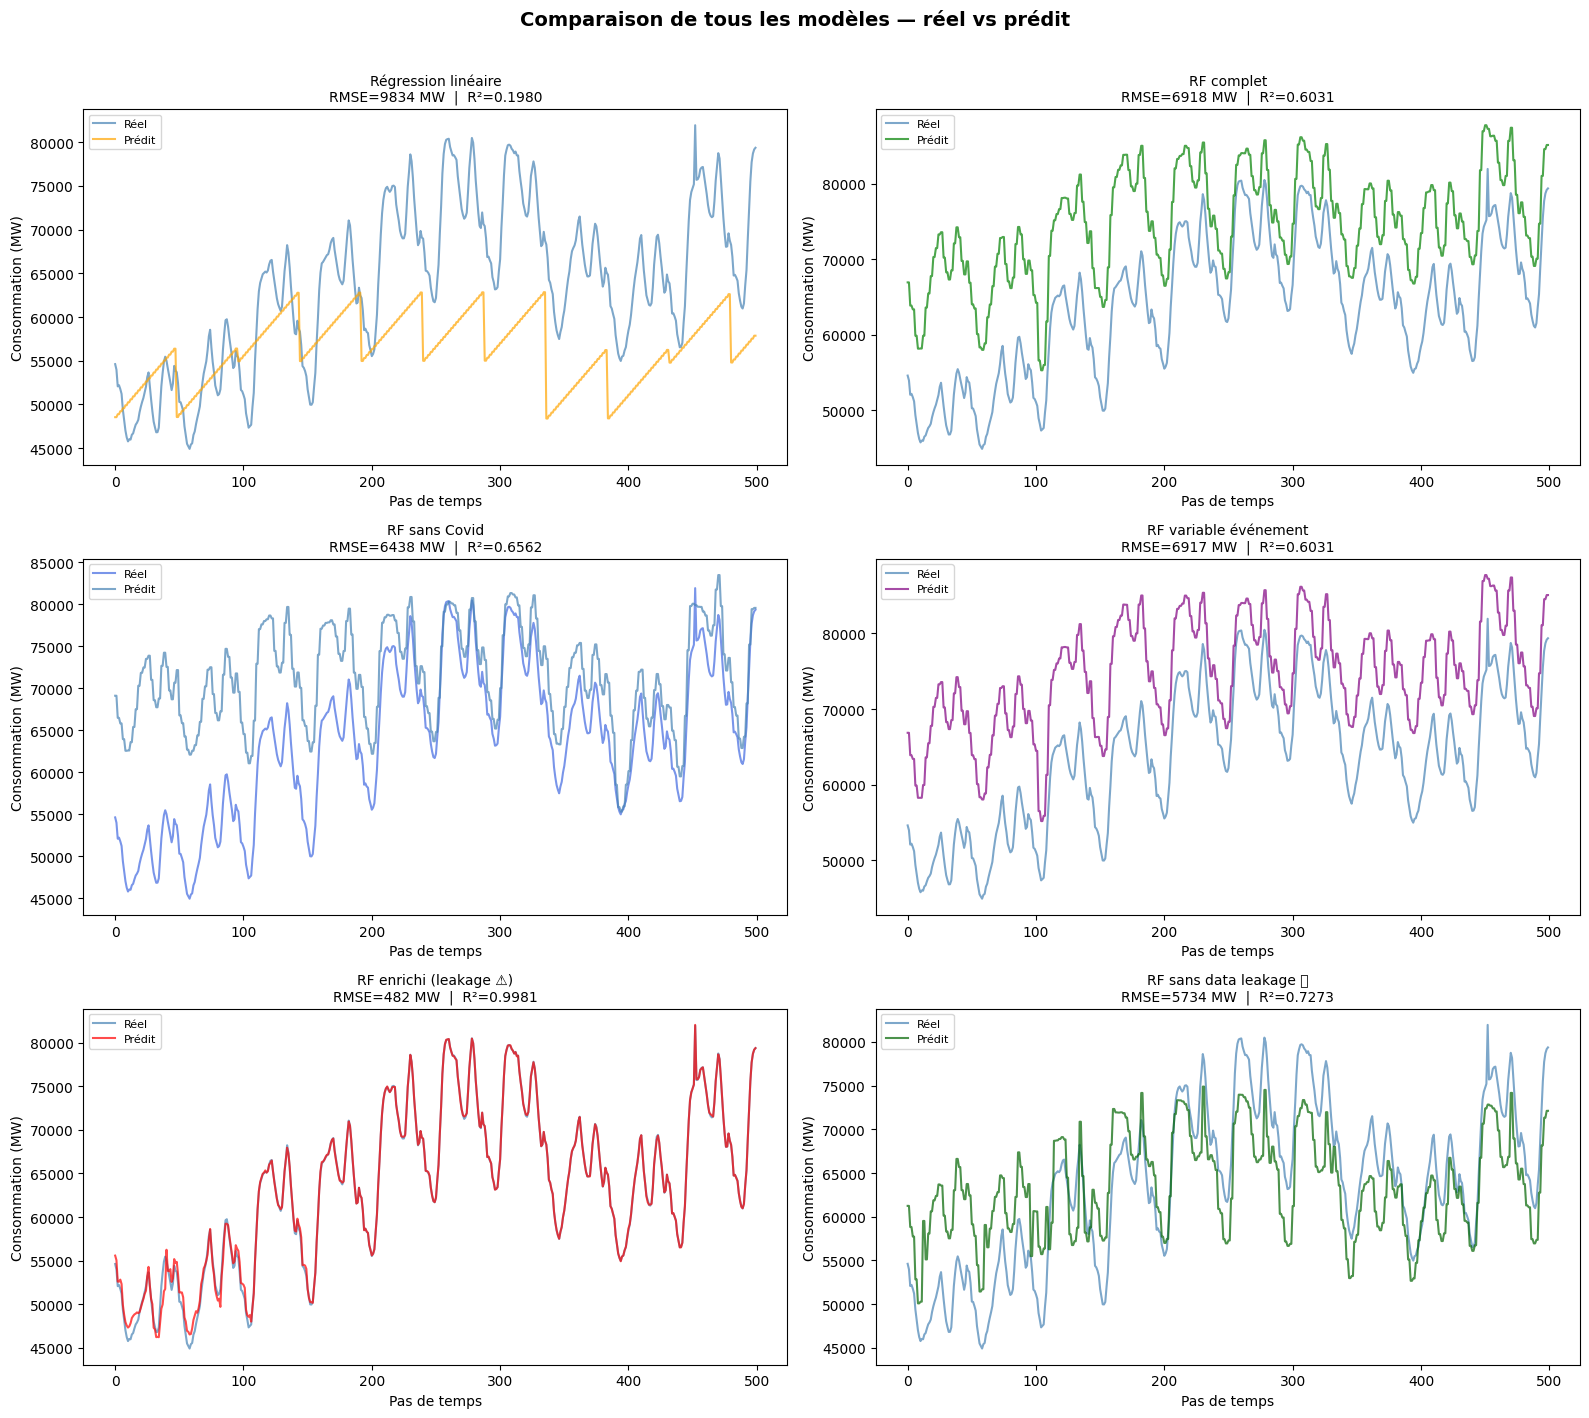

In [31]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

modeles_info = [
    (y_test.values,   y_pred_lr, "Régression linéaire",              "orange"),
    (y_test.values,   y_pred_rf, "RF complet",                       "green"),
    (y_test_A.values, y_pred_A,  "RF sans Covid",                    "steelblue"),
    (y_test_B.values, y_pred_B,  "RF variable événement",            "purple"),
    (y_test_C.values, y_pred_C,  "RF enrichi (leakage ⚠️)",          "red"),
    (y_test_D.values, y_pred_D,  "RF sans data leakage ✅",          "darkgreen"),
]

sample = 500

for i, (y_reel, y_pred, titre, couleur) in enumerate(modeles_info):
    axes[i].plot(y_reel[:sample], label="Réel", alpha=0.7, color="steelblue" if couleur != "steelblue" else "royalblue")
    axes[i].plot(y_pred[:sample], label=f"Prédit", alpha=0.7, color=couleur)
    
    # Récupérer les métriques correspondantes
    rmse_val = [rmse_lr, rmse_rf, rmse_A, rmse_B, rmse_C, rmse_D][i]
    r2_val   = [r2_lr,   r2_rf,   r2_A,   r2_B,   r2_C,   r2_D][i]
    
    axes[i].set_title(f"{titre}\nRMSE={rmse_val:.0f} MW  |  R²={r2_val:.4f}", fontsize=10)
    axes[i].set_xlabel("Pas de temps")
    axes[i].set_ylabel("Consommation (MW)")
    axes[i].legend(fontsize=8)

plt.suptitle("Comparaison de tous les modèles — réel vs prédit", 
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

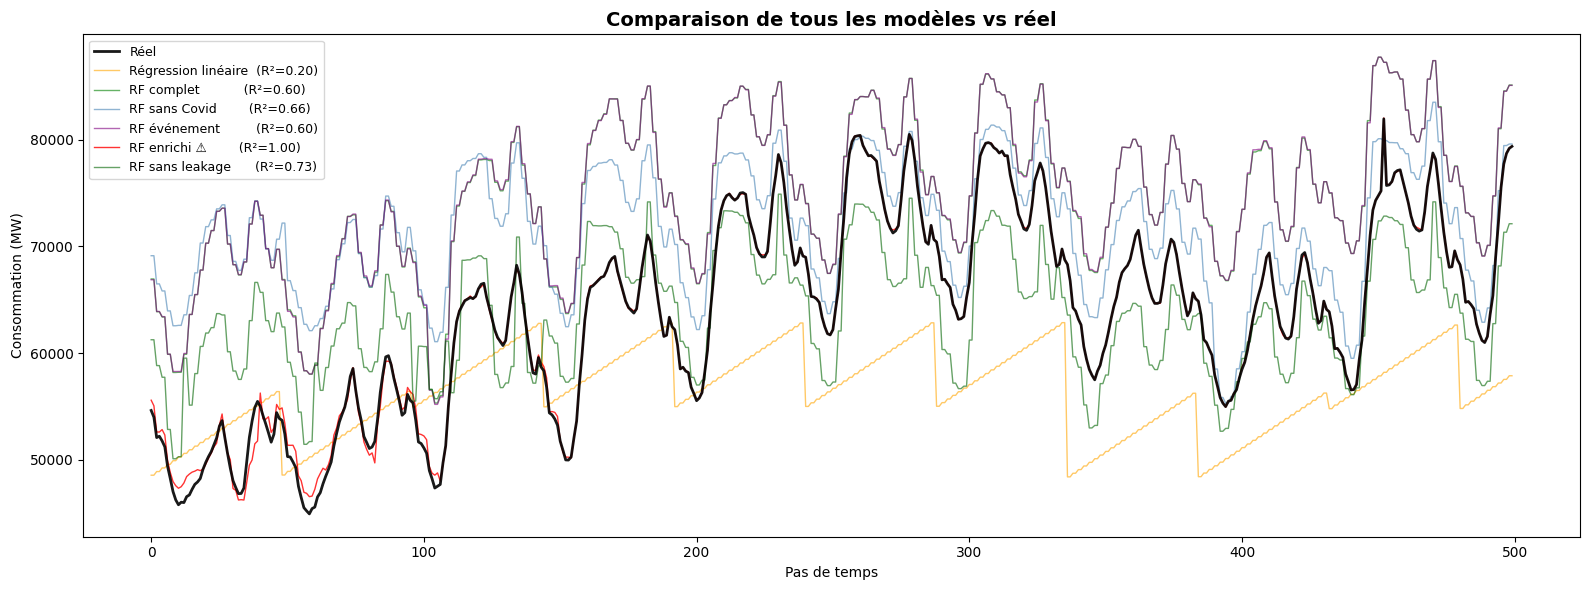

In [33]:
sample = 500

plt.figure(figsize=(16, 6))

# Réel en noir épais pour bien le voir
plt.plot(y_test_D.values[:sample], label="Réel", 
         color="black", linewidth=2, alpha=0.9, zorder=10)

# Tous les modèles
plt.plot(y_pred_lr[:sample],  label=f"Régression linéaire  (R²={r2_lr:.2f})",  color="orange",    alpha=0.6, linewidth=1)
plt.plot(y_pred_rf[:sample],  label=f"RF complet           (R²={r2_rf:.2f})",  color="green",     alpha=0.6, linewidth=1)
plt.plot(y_pred_A[:sample],   label=f"RF sans Covid        (R²={r2_A:.2f})",   color="steelblue", alpha=0.6, linewidth=1)
plt.plot(y_pred_B[:sample],   label=f"RF événement         (R²={r2_B:.2f})",   color="purple",    alpha=0.6, linewidth=1)
plt.plot(y_pred_C[:sample],   label=f"RF enrichi ⚠️        (R²={r2_C:.2f})",   color="red",       alpha=0.8, linewidth=1)
plt.plot(y_pred_D[:sample],   label=f"RF sans leakage      (R²={r2_D:.2f})",   color="darkgreen", alpha=0.6, linewidth=1)

plt.title("Comparaison de tous les modèles vs réel", fontsize=14, fontweight="bold")
plt.xlabel("Pas de temps")
plt.ylabel("Consommation (MW)")
plt.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()